In [1]:
from scipy.linalg import solve
import numpy as np
import matplotlib.pyplot as plt


def D_geo(D0, D1, u, v):
    lam = v / (u + v)
    D_tem = D0 + 1 / (1 - lam) * D1
    N = D_tem.shape[0]
    for i in range(N):
        s = 0
        for j in range(N):
            if j != i:
                s += D_tem[i, j]
        D_tem[i, i] = -s
    return D_tem


def stationary_distribution(D):
    N = D.shape[0]
    A = D.T.copy()
    A[-1, :] = 1.0
    b = np.zeros(N)
    b[-1] = 1.0
    pi = np.linalg.solve(A, b)
    return pi.reshape(1, -1)


def compute_expr1_expr2(D, D1, pi, u, v, delta=1.0):
    N = D.shape[0]
    I = np.eye(N)
    ones = np.ones((N, 1))

    term1 = (pi @ D1 @ ones)[0, 0]

    X_delta = solve(delta * I - D, D1 @ ones)
    X_u = solve(u * I - D, D1 @ ones)
    X_u_delta = solve(u * I - D, X_delta)

    term2 = (pi @ D1 @ X_delta)[0, 0]
    term3 = (pi @ D1 @ X_u)[0, 0]
    term4 = (pi @ D1 @ X_u_delta)[0, 0]

    expr1 = (
        v * (u + v) ** 2 / (2 * u ** 3 * delta) * term1
        + (u + v) ** 4 / (2 * u ** 4 * delta) * term2
    )

    expr2 = (
        (u + v) ** 2 / (2 * u ** 2 * delta * (u + delta))
        * (
            v * term1
            + (u + v) ** 2 * term4
            + ((u + v) ** 2 / u) * term3
        )
    )

    return expr1, expr2


def bound_B2_error(D, D1, u, v, delta=1.0):
    D1_inf = np.linalg.norm(D1, ord=np.inf)
    D_inf = np.linalg.norm(D, ord=np.inf)

    bound = (
        v * (u + v) ** 2 / (2 * u ** 3 * (u + delta)) * D1_inf
        + (u + v) ** 4 / (2 * u ** 5 * delta * (u + delta))
        * (D1_inf ** 2)
        * D_inf
    )
    return bound


def compute_abs_diff_and_bound(
    D0,
    D1,
    v,
    delta=1.0,
    u_min=1.0,
    u_max=100.0,
    num_points=1000
):

    u_values = np.linspace(u_min, u_max, num_points)
    abs_diff_values = []
    bound_values = []

    for u in u_values:
        D = D_geo(D0, D1, u,v)
        pi = stationary_distribution(D)
        expr1, expr2 = compute_expr1_expr2(D, D1, pi, u, v, delta)
        abs_diff = abs(expr1 - expr2)
        bound = bound_B2_error(D, D1, u, v, delta)

        abs_diff_values.append(abs_diff)
        bound_values.append(bound)

    return (
        D,
        pi,
        u_values,
        np.array(abs_diff_values),
        np.array(bound_values)
    )


D0 = np.array([
    [0, 0, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 0, 0]
], dtype=float)

D1 = np.array([
    [0.2, 0.2, 0.1, 0.8],
    [0.2, 0.2, 0.1, 0.8],
    [0.1, 0.1, 0.1, 0.0],
    [0.8, 0.8, 0.0, 0.8]
], dtype=float)

delta = 1.0
v = 2

D, pi, u_values, abs_diff_values, bound_values = (
    compute_abs_diff_and_bound(
        D0=D0,
        D1=D1,
        v=v,
        delta=delta,
        u_min=10.0,
        u_max=1000.0,
        num_points=100
    )
)

is_valid = np.all(bound_values >= abs_diff_values)
min_margin = np.min(bound_values - abs_diff_values)

print("D =")
print(D)
print()
print("pi =")
print(pi)
print()
print("||D1||_inf =", np.linalg.norm(D1, ord=np.inf))
print("||D||_inf =", np.linalg.norm(D, ord=np.inf))
print()
print("Does the upper bound hold at every point?", is_valid)
print("min(bound - abs_diff) =", min_margin)


D =
[[-1.1022  0.2004  0.1002  0.8016]
 [ 0.2004 -1.1022  0.1002  0.8016]
 [ 0.1002  0.1002 -0.2004  0.    ]
 [ 0.8016  0.8016  0.     -1.6032]]

pi =
[[0.25 0.25 0.25 0.25]]

||D1||_inf = 2.4000000000000004
||D||_inf = 3.2064000000000004

Does the upper bound hold at every point? True
min(bound - abs_diff) = 1.0274594066134406e-05


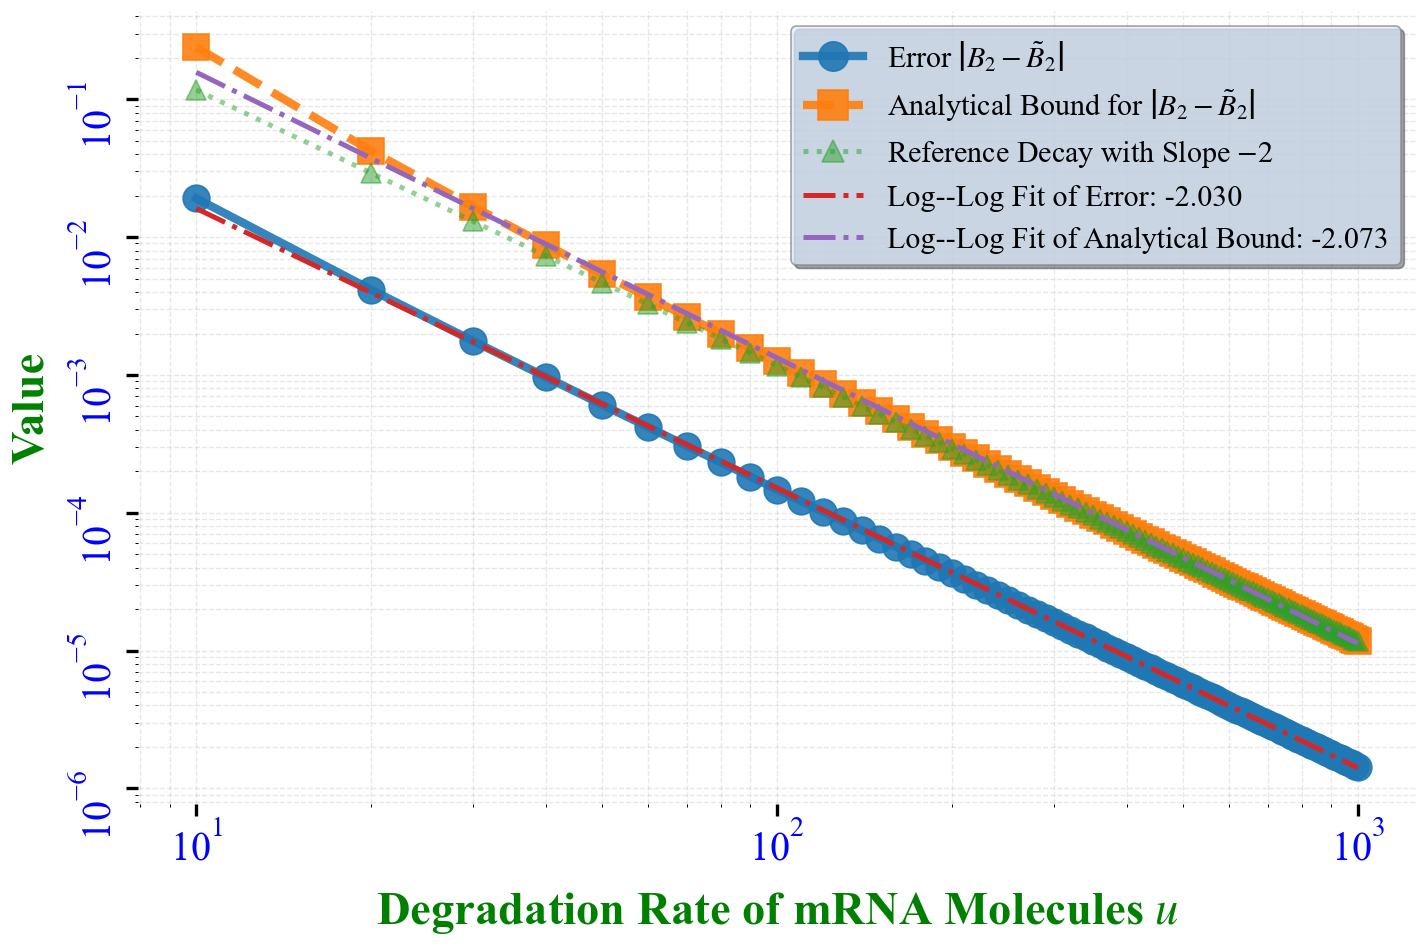

Slope of abs_diff_values on log-log scale: -2.029718
Slope of bound_values on log-log scale:    -2.072630


In [2]:
plt.rcParams["axes.linewidth"] = 2
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "stix"

fig, ax = plt.subplots(figsize=(12, 8), dpi=120)

C = bound_values[-1] * u_values[-1] ** 2
ref_values = C / u_values ** 2

mask_abs = (
    (u_values > 0)
    & (abs_diff_values > 0)
    & np.isfinite(u_values)
    & np.isfinite(abs_diff_values)
)

mask_bound = (
    (u_values > 0)
    & (bound_values > 0)
    & np.isfinite(u_values)
    & np.isfinite(bound_values)
)

slope_abs, intercept_abs = np.polyfit(
    np.log10(u_values[mask_abs]),
    np.log10(abs_diff_values[mask_abs]),
    1
)

slope_bound, intercept_bound = np.polyfit(
    np.log10(u_values[mask_bound]),
    np.log10(bound_values[mask_bound]),
    1
)

fit_abs = 10 ** intercept_abs * u_values ** slope_abs
fit_bound = 10 ** intercept_bound * u_values ** slope_bound

ax.loglog(
    u_values,
    abs_diff_values,
    linestyle="-",
    marker="o",
    linewidth=5,
    markersize=16,
    alpha=0.9,
    label=rf"Error $\left|B_{{2}}-\tilde{{B}}_{{2}}\right|$"
)

ax.loglog(
    u_values,
    bound_values,
    linestyle="--",
    marker="s",
    linewidth=5,
    markersize=16,
    alpha=0.9,
    label=(
        rf"Analytical Bound for "
        rf"$\left|B_{{2}}-\tilde{{B}}_{{2}}\right|$"
    )
)

ax.loglog(
    u_values,
    ref_values,
    linestyle=":",
    marker="^",
    linewidth=3,
    markersize=12,
    alpha=0.5,
    label=r"Reference Decay with Slope $-2$"
)

ax.loglog(
    u_values,
    fit_abs,
    linestyle="-.",
    linewidth=3,
    alpha=1,
    label=rf"Log--Log Fit of Error: {slope_abs:.3f}"
)

ax.loglog(
    u_values,
    fit_bound,
    linestyle="-.",
    linewidth=3,
    alpha=1,
    label=rf"Log--Log Fit of Analytical Bound: {slope_bound:.3f}"
)

# ax.set_title(
#     r"Difference and Upper Bound of Second-Order Binomial Moments",
#     fontsize=24,
#     fontweight="bold",
#     color="green",
#     pad=15
# )

ax.set_xlabel(
    r"Degradation Rate of mRNA Molecules $u$",
    fontsize=28,
    fontweight="bold",
    color="green",
    labelpad=12
)

ax.set_ylabel(
    "Value",
    fontsize=28,
    fontweight="bold",
    color="green",
    labelpad=12
)

ax.tick_params(
    direction="out",
    width=2,
    length=7,
    labelsize=24
)

for label in ax.get_xticklabels():
    label.set_fontname("Times New Roman")
    label.set_color("blue")

for label in ax.get_yticklabels():
    label.set_fontname("Times New Roman")
    label.set_color("blue")
    label.set_rotation(90)

ax.grid(
    True,
    which="both",
    linestyle="--",
    alpha=0.3
)

legend = ax.legend(
    loc="upper right",
    frameon=True,
    fancybox=True,
    shadow=True,
    markerscale=1.1,
    prop={
        "family": "Times New Roman",
        "size": 18
    }
)

legend.get_frame().set_edgecolor("gray")
legend.get_frame().set_facecolor("#DCEBFF")
legend.get_frame().set_alpha(0.7)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig(
    "Fig4.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=600
)
plt.show()

print(
    f"Slope of abs_diff_values on log-log scale: "
    f"{slope_abs:.6f}"
)
print(
    f"Slope of bound_values on log-log scale:    "
    f"{slope_bound:.6f}"
)
